https://www.kaggle.com/datasets/govindaramsriram/energy-consumption-dataset-linear-regression

# GET THE DATA

In [52]:
import pandas as pd
dataset = pd.read_csv('../../datasets/test_energy_data.csv')

# EDA + PREPROCESSING 1

#### VIEW ANALYZE

In [53]:
dataset.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,24563,15,4,28.52,Weekday,2865.57
1,Commercial,27583,56,23,23.07,Weekend,4283.80
2,Commercial,45313,4,44,33.56,Weekday,5067.83
3,Residential,41625,84,17,27.39,Weekend,4624.30
4,Residential,36720,58,47,17.08,Weekday,4820.59


In [54]:
dataset.nunique()

Building Type            3
Square Footage          99
Number of Occupants     65
Appliances Used         45
Average Temperature     99
Day of Week              2
Energy Consumption     100
dtype: int64

In [55]:
dataset['Building Type'].value_counts()

Building Type
Residential    40
Industrial     34
Commercial     26
Name: count, dtype: int64

In [56]:
dataset.shape

(100, 7)

#### STRUCTURE AND FEATURES QUALITY

In [57]:
# NULL VALUES

dataset.isnull().sum()

Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64

In [58]:
dataset.duplicated().sum()

np.int64(0)

#### PLOTS 

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

In [60]:
# VERIFY IF ANY FEATURE HAVE SKEW

dataset_is_skew = dataset.drop(columns=["Building Type", "Day of Week"])
dataset_is_skew.skew()

Square Footage        -0.218762
Number of Occupants    0.159334
Appliances Used       -0.150855
Average Temperature    0.007284
Energy Consumption    -0.242143
dtype: float64

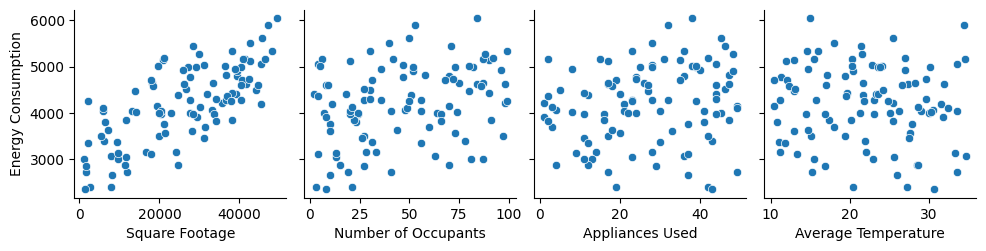

In [61]:
# VERIFY IF OUTLIERS
columns = ['Square Footage', 'Number of Occupants', 'Appliances Used', "Average Temperature"]
sns.pairplot(data = dataset, x_vars = columns, y_vars = "Energy Consumption")
plt.show()

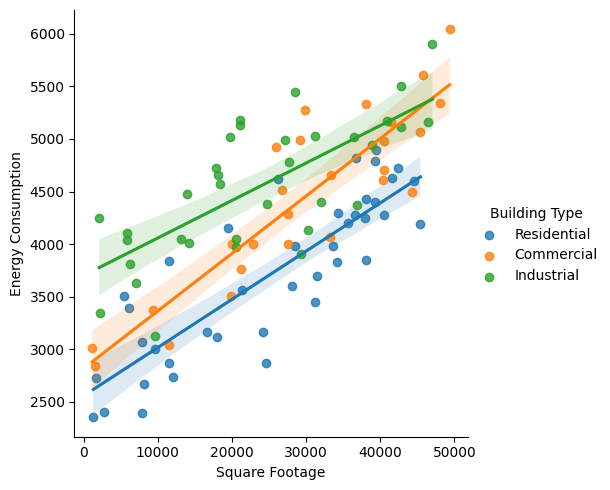

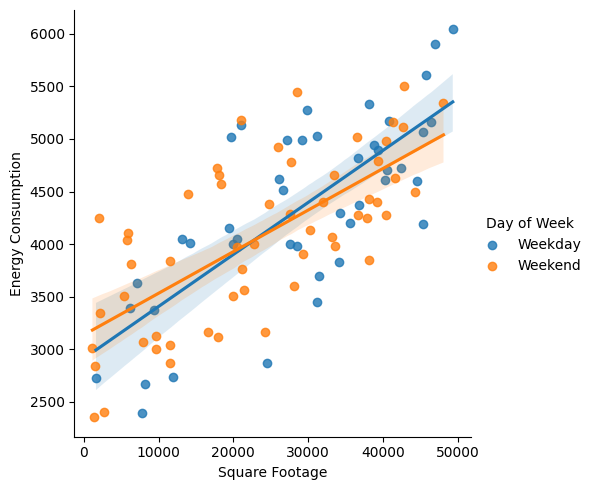

In [62]:
sns.lmplot(data=dataset, x='Square Footage', y='Energy Consumption', hue='Building Type')
sns.lmplot(data=dataset, x='Square Footage', y='Energy Consumption', hue='Day of Week')
plt.show()

# SPLIT PART

In [63]:
x = dataset.drop(columns= ["Energy Consumption"])
x.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week
0,Residential,24563,15,4,28.52,Weekday
1,Commercial,27583,56,23,23.07,Weekend
2,Commercial,45313,4,44,33.56,Weekday
3,Residential,41625,84,17,27.39,Weekend
4,Residential,36720,58,47,17.08,Weekday


In [64]:
y = dataset[['Energy Consumption']]
y.head()

,Energy Consumption
0,2865.57
1,4283.80
2,5067.83
3,4624.30
4,4820.59


In [65]:
from sklearn.model_selection import train_test_split

X_train, x_test, Y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)


# PREPROCESSING + MODEL FIT

In [72]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

columns_scaler = ['Square Footage', 'Number of Occupants', 'Appliances Used', "Average Temperature"]
column_one = ['Day of Week']
column_ordinal = ["Building Type"]

transformer = ColumnTransformer(
    transformers=[
        ("one hot encoder", OneHotEncoder(), column_one),
        ("ordinal encoder", OrdinalEncoder(), column_ordinal),
        ("Scaler encoder", StandardScaler(), columns_scaler),
     ],
     remainder="passthrough"
    )

# TRAIN
pipe = Pipeline([
    ("preprocessing", transformer),
    ("Model", LinearRegression())
])

# FIT 
pipe.fit(X_train, Y_train)


# ACCURACY TEST PART
y_preds_test = pipe.predict(x_test)
r2_test = r2_score(y_test, y_preds_test)
print(f"The accuracy of the model are: {r2_test*100:.2f}")


The accuracy of the model are: 81.57
